In [1]:
# import necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
import seaborn as sns
from libpysal.weights import DistanceBand, KNN
from esda.moran import Moran
from spreg import OLS, ML_Error, ML_Lag, GM_Error, GM_Lag
from scipy import stats
from shapely.geometry import Point
from splot.esda import moran_scatterplot, plot_moran
import contextily as ctx
from matplotlib.ticker import FuncFormatter
import pyproj
from libpysal.weights import lag_spatial
from scipy.stats import norm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import BayesianRidge

In [3]:
# Helper functions: Check missing values and print summary after cleaning
def after_clean(df, step_name, df_before_rows):
    rows_now = len(df)
    cols_now = len(df.columns)
    dropped = df_before_rows - rows_now
    print(f"[{step_name}] Rows after cleaning: {rows_now} | Rows dropped this step: {dropped} | Current columns: {cols_now}")
    return rows_now

In [4]:
# Read the dataset and print initial summary
listings = pd.read_csv(r'Data/2024-10-18_listings.csv.gz')
listings.head()
print(listings.shape)
print(listings.columns)

rows = len(listings)
print(f"[Start] Initial rows: {rows} | Initial columns: {len(listings.columns)}")

(5629, 75)
Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_av

In [5]:
# Check missing values (24 variables)
cols_to_clean = [
    'number_of_reviews', 'price', 'reviews_per_month',
    'room_type', 'accommodates', 'availability_30',
    'bathrooms_text', 'bedrooms', 'beds',
    'property_type', 'host_since',
    'host_response_time', 'host_response_rate', 'host_acceptance_rate',
    'host_listings_count', 'calculated_host_listings_count',
    'host_is_superhost', 'host_identity_verified', 'host_has_profile_pic',
    'has_availability', 'instant_bookable', 'minimum_nights', 'maximum_nights',
    'amenities'
]

missing_summary = pd.DataFrame({
    'Missing count': listings[cols_to_clean].isna().sum(),
    'Missing percentage (%)': (listings[cols_to_clean].isna().sum() / len(listings) * 100).round(2)
})
print(missing_summary)

                                Missing count  Missing percentage (%)
number_of_reviews                           0                    0.00
price                                     946                   16.81
reviews_per_month                         413                    7.34
room_type                                   0                    0.00
accommodates                                0                    0.00
availability_30                             0                    0.00
bathrooms_text                              7                    0.12
bedrooms                                  243                    4.32
beds                                      958                   17.02
property_type                               0                    0.00
host_since                                  0                    0.00
host_response_time                        348                    6.18
host_response_rate                        348                    6.18
host_acceptance_rate

In [6]:
# 1. Clean the Reviews
# Requirements: Remove missing values, trim above 95th percentile, log-transform

target_col = 'number_of_reviews'
listings[target_col] = pd.to_numeric(listings[target_col], errors='coerce')

# Remove missing values
listings = listings.dropna(subset=[target_col])

# trim above 95th percentile
p95_reviews = listings[target_col].quantile(0.95)
listings = listings[listings[target_col] <= p95_reviews]

#log-transform
listings['log_reviews'] = np.log1p(listings[target_col])

print(listings[['number_of_reviews', 'log_reviews']].head())

   number_of_reviews  log_reviews
1                346     5.849325
2                 74     4.317488
4                 91     4.521789
5                 36     3.610918
6                332     5.808142


In [7]:
# Check the missing values again after cleaning
rows = after_clean(listings, '1. Reviews', rows)
# There were no missing values in the Reviews, but the 95th percentile truncated and removed 280 extremely high rated properties (approximately 5% of the original data)

[1. Reviews] Rows after cleaning: 5349 | Rows dropped this step: 280 | Current columns: 76


In [8]:
# 2. Clean price - convert only, keep NaN for later imputation
listings['price'] = listings['price'].replace(r'[\$,]', '', regex=True)
listings['price'] = pd.to_numeric(listings['price'], errors='coerce')

# Mark which rows have missing price BEFORE imputation
listings['price_imputed'] = listings['price'].isna().astype(int)

print(f"Step 2 done. Missing price values (to be imputed later): {listings['price'].isnull().sum()}")
rows = after_clean(listings, '2. Price (convert only, no drop)', rows)

Step 2 done. Missing price values (to be imputed later): 935
[2. Price (convert only, no drop)] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 77


In [9]:
# 3. Clean the Service activity
# Requirement:Create inactive indicator from  reviews per month and impute missing review rates as zero
# impute missing review rates as zero
listings['reviews_per_month'] = listings['reviews_per_month'].fillna(0)
# Create inactive indicator(1 if reviews_per_month == 0, else 0)
listings['inactive'] = (listings['reviews_per_month'] == 0).astype(int)
print(listings['inactive'].value_counts())

inactive
0    4936
1     413
Name: count, dtype: int64


In [10]:
# Check the missing values again after cleaning
rows = after_clean(listings, '3. Service Activity', rows)

[3. Service Activity] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 78


In [11]:
# 4. Clean the Room type
# Requirement:Map room categories to numeric codes: 'Private room', 'Entire home/apt', 'Shared room', 'Hotel room'
# Create a mapping dictionary
room_type_mapping = {
    'Private room': 1,
    'Entire home/apt': 2,
    'Shared room': 3,
    'Hotel room': 4
}
# Map room categories to numeric codes
listings['room_type_code'] = listings['room_type'].map(room_type_mapping)
print(listings['room_type_code'].value_counts())
print(listings[['room_type', 'room_type_code']].head())

room_type_code
2    3692
1    1613
3      31
4      13
Name: count, dtype: int64
         room_type  room_type_code
1  Entire home/apt               2
2  Entire home/apt               2
4  Entire home/apt               2
5  Entire home/apt               2
6  Entire home/apt               2


In [12]:
# Check the missing values again after cleaning
rows = after_clean(listings, '4. Room Type', rows)

[4. Room Type] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 79


In [13]:
# 5. Clean the Accommodates
# Requirement: Derive max. number of guests
# Ensure that it is numeric and set non convertible values to NaN
listings['accommodates'] = pd.to_numeric(listings['accommodates'], errors='coerce')

# Remove missing values (if any), as NaN cannot be directly converted to int
listings = listings.dropna(subset=['accommodates'])

# Transform to Integer
listings['accommodates'] = listings['accommodates'].astype(int)
print(listings['accommodates'].head())

1    4
2    2
4    4
5    6
6    5
Name: accommodates, dtype: int64


In [14]:
# Check the missing values again after cleaning
rows = after_clean(listings, '5. Accommodates', rows)

[5. Accommodates] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 79


In [15]:
#　6. Clean the Availability
# Requirement:Clean availability set within 30 days
# Ensure that availability_30 is numeric and set non convertible values to NaN
listings['availability_30'] = pd.to_numeric(listings['availability_30'], errors='coerce').fillna(0).astype(int)
print(listings['availability_30'].head())

1     2
2     1
4     3
5    10
6     0
Name: availability_30, dtype: int64


In [16]:
# Check the missing values again after cleaning
rows = after_clean(listings, '6. Availability', rows)

[6. Availability] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 79


In [17]:
# 7. Clean the Bathrooms（Using imputation method）
# Requirement: Clean bedroom descriptions
# Ensure that bathrooms is numeric
extracted_baths = listings['bathrooms_text'].astype(str).str.extract(r'(\d+\.?\d*)')[0]
listings['bathrooms'] = pd.to_numeric(extracted_baths, errors='coerce')
# Fill missing with median instead of dropping
listings['bathrooms'] = listings['bathrooms'].fillna(listings['bathrooms'].median())

# Upward rounding (e.g. 1.5->2) and converting to an integer (Integer)
listings['bathrooms'] = np.ceil(listings['bathrooms']).astype(int)

print(listings['bathrooms'].head())

1    2
2    2
4    1
5    2
6    1
Name: bathrooms, dtype: int64


In [18]:
# Check the missing values again after cleaning
rows = after_clean(listings, '7. Bathrooms', rows)

[7. Bathrooms] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 79


In [19]:
# 8. Clean the Bedrooms(Using imputation method)
listings['bedrooms'] = pd.to_numeric(listings['bedrooms'], errors='coerce')
# Fill missing with median instead of dropping
listings['bedrooms'] = listings['bedrooms'].fillna(listings['bedrooms'].median()).astype(int)
print(listings['bedrooms'].head())

1    2
2    1
4    2
5    3
6    3
Name: bedrooms, dtype: int64


In [20]:
# Check the missing values again after cleaning
rows = after_clean(listings, '8. Bedrooms', rows)

[8. Bedrooms] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 79


In [21]:
# 9. Clean the Beds(Using imputation method)
listings['beds'] = pd.to_numeric(listings['beds'], errors='coerce')
# Fill missing with median instead of dropping (beds has 17% missing)
listings['beds'] = listings['beds'].fillna(listings['beds'].median()).astype(int)
print(listings['beds'].head())

1    2
2    2
4    2
5    2
6    4
Name: beds, dtype: int64


In [22]:
# Check the missing values again after cleaning
rows = after_clean(listings, '9. Beds', rows)

[9. Beds] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 79


In [23]:
# 10. Clean the Property type
# Requirement: Encode property, such as Private room, Entire home,  categories as factors
# Step 1 : Check the distribution of raw property types
prop_type_dist = listings['property_type'].value_counts()
print("Raw property_type category distribution (Top 10):\n", prop_type_dist.head(10))
print(f"\nTotal number of raw categories: {len(prop_type_dist)}")


Raw property_type category distribution (Top 10):
 property_type
Entire rental unit             2217
Entire condo                    882
Private room in rental unit     584
Private room in condo           370
Private room in home            308
Entire home                     284
Private room in townhouse       117
Entire serviced apartment        71
Room in hotel                    68
Entire townhouse                 56
Name: count, dtype: int64

Total number of raw categories: 52


In [24]:
# Step 2: Define category aggregation rules
def aggregate_property_type(prop_type):
    prop = str(prop_type).strip().lower()
    
    # Major Category 1: Entire home/apt (covers all "Entire ..." types)
    if prop.startswith('entire'):
        return 'Entire home/apt'
    
    # Major Category 2: Private room (covers all "Private room ..." types)
    elif prop.startswith('private room'):
        return 'Private room'
    
    # Major Category 3: Shared room (covers all "Shared room ..." types, if any)
    elif prop.startswith('shared room'):
        return 'Shared room'
    
    # Major Category 4: Unique stays (covers all other niche types like "Boat", "Castle", "Room in hotel")
    else:
        return 'Unique stays'

# Step 3: Apply aggregation rules
listings['property_type_aggregated'] = listings['property_type'].apply(aggregate_property_type)

# Check distribution of aggregated categories (validate aggregation effect)
print("\nAggregated property_type distribution:")
print(listings['property_type_aggregated'].value_counts())

# Step 4: One-Hot encode aggregated major categories
property_onehot = pd.get_dummies(
    listings['property_type_aggregated'], 
    prefix='property', 
    drop_first=True  # Avoid multicollinearity
)

# Merge One-Hot encoded columns back to the original dataset
listings = pd.concat([listings, property_onehot], axis=1)

#Step 5: Validate final results
print("\nNew columns added after One-Hot encoding:")
print(property_onehot.columns.tolist())
print(f"\nNumber of columns in dataset after encoding: {listings.shape[1]}")


Aggregated property_type distribution:
property_type_aggregated
Entire home/apt    3644
Private room       1521
Unique stays        153
Shared room          31
Name: count, dtype: int64

New columns added after One-Hot encoding:
['property_Private room', 'property_Shared room', 'property_Unique stays']

Number of columns in dataset after encoding: 83


In [25]:
# Check the missing values again after cleaning
missing_aggregated = listings['property_type_aggregated'].isnull().sum()
print(f"\nMissing values in 'property_type_aggregated': {missing_aggregated}")
rows = after_clean(listings, '10. Property Type', rows)


Missing values in 'property_type_aggregated': 0
[10. Property Type] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 83


In [26]:
# 11. Clean the Hosting history
listings['host_since'] = pd.to_datetime(listings['host_since'], errors='coerce')
listings = listings.dropna(subset=['host_since'])  # only drop truly missing host_since

scrape_date = pd.to_datetime('2024-10-18')
listings['host_since'] = (scrape_date - listings['host_since']).dt.days
listings['host_since'] = listings['host_since'].astype(int)

# Fill missing maximum_nights instead of dropping
listings['maximum_nights'] = listings['maximum_nights'].fillna(365).astype(int)
print(listings['host_since'].head())

1    5480
2    5211
4    5146
5    5127
6    5115
Name: host_since, dtype: int64


In [27]:
# Check the missing values again after cleaning
rows = after_clean(listings, '11. Hosting History', rows)

[11. Hosting History] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 83


In [28]:
# 12. Clean the Host response time
# Requirement: Map host response time categories:  none, 'within an hour', 'within a few hours', 'within a day', 'a few days or more'.
# Unified all lowercase to prevent inconsistent formatting
# There is indeed a difference in response speed between fast and slow.
listings['host_response_time'] = listings['host_response_time'].fillna('none')
listings['host_response_time'] = listings['host_response_time'].str.lower()

response_time_order = [
    'none',
    'within an hour',
    'within a few hours',
    'within a day',
    'a few days or more'
]
    
    # Ordered Categorical
listings['host_response_time'] = pd.Categorical(
        listings['host_response_time'],
        categories=response_time_order,
        ordered=True  
    )
    
    # code rules：none=0, within an hour=1, within a few hours=2, within a day=3, a few days or more=4
listings['host_response_time_code'] = listings['host_response_time'].cat.codes

print(listings['host_response_time'].value_counts(sort=False))

host_response_time
none                   340
within an hour        4007
within a few hours     565
within a day           304
a few days or more     133
Name: count, dtype: int64


In [29]:
# Check the missing values again after cleaning
rows = after_clean(listings, '12. Host Response Time', rows)

[12. Host Response Time] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 84


In [30]:
for code, cat in enumerate(listings['host_response_time'].cat.categories):
    count = (listings['host_response_time_code'] == code).sum()
    print(f"{cat:<25} → code: {code:>2}, count: {count:>5}")

none                      → code:  0, count:   340
within an hour            → code:  1, count:  4007
within a few hours        → code:  2, count:   565
within a day              → code:  3, count:   304
a few days or more        → code:  4, count:   133


In [31]:
# 13. Clean the Host response rate
# Requirement: Clean host response rate
listings['host_response_rate'] = listings['host_response_rate'].str.replace('%', '').astype(float)
listings['host_response_rate'] = listings['host_response_rate'].round().astype('Int64')
listings['host_response_rate'] = listings['host_response_rate'].fillna(0)

listings['host_response_rate'] = listings['host_response_rate'].astype(str) + '%'

print(listings['host_response_rate'].head())

1    100%
2    100%
4     94%
5    100%
6      0%
Name: host_response_rate, dtype: str


In [32]:
# Check the missing values again after cleaning
rows = after_clean(listings, '13. Host Response Rate', rows)

[13. Host Response Rate] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 84


In [33]:
# 14. Clean the Host acceptance rate
# Requirement: Clean host acceptance rate
listings['host_acceptance_rate'] = listings['host_acceptance_rate'].str.replace('%', '').astype(float)
listings['host_acceptance_rate'] = listings['host_acceptance_rate'].round().astype('Int64')
listings['host_acceptance_rate'] = listings['host_acceptance_rate'].fillna(0)

listings['host_acceptance_rate'] = listings['host_acceptance_rate'].astype(str) + '%'

print(listings['host_acceptance_rate'].head())

1    100%
2    100%
4    100%
5    100%
6      0%
Name: host_acceptance_rate, dtype: str


In [34]:
# Check the missing values again after cleaning
rows = after_clean(listings, '14. Host Acceptance Rate', rows)

[14. Host Acceptance Rate] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 84


In [35]:
# 15&16. Clean the Professionalization
# Requirement: Aggregated number of listings hosted and Derived matrix based on listings managed by host - <68% correlation with host_listings_count
listings['host_listings_count'] = listings['host_listings_count'].astype('Int64')
listings['host_listings_count'] = listings['host_listings_count'].fillna(0)

listings['calculated_host_listings_count'] = listings['calculated_host_listings_count'].fillna(0).astype('Int64')

# Check correlation (validate <68%)
corr = listings[['host_listings_count', 'calculated_host_listings_count']].corr().iloc[0,1]
print(f"Correlation between host_listings_count and calculated_host_listings_count: {corr:.2%}")

Correlation between host_listings_count and calculated_host_listings_count: 16.46%


In [36]:
# Check the missing values again after cleaning
rows = after_clean(listings, '15&16. Professionalization', rows)

[15&16. Professionalization] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 84


In [37]:
# 17. Clean the Platform attributes
# Requirement: Binary encode availability, instant booking, verification, superhost and host identities
# The original string is t/f, which is converted into binary variables of 0/1.
# has_availability
listings['has_availability'] = (listings['has_availability'] == 't').astype(int)
# instant_bookable
listings['instant_bookable'] = (listings['instant_bookable'] == 't').astype(int)
# host_has_profile_pic
listings['host_has_profile_pic'] = (listings['host_has_profile_pic'] == 't').astype(int)
# host_is_superhost
listings['host_is_superhost'] = (listings['host_is_superhost'] == 't').astype(int)
# host_identity_verified
listings['host_identity_verified'] = (listings['host_identity_verified'] == 't').astype(int)

print(listings[['has_availability', 'instant_bookable', 'host_has_profile_pic', 'host_is_superhost', 'host_identity_verified']].value_counts())

has_availability  instant_bookable  host_has_profile_pic  host_is_superhost  host_identity_verified
1                 0                 1                     1                  1                         1601
                                                          0                  1                         1439
                  1                 1                     0                  1                         1143
                                                          1                  1                          669
                  0                 1                     0                  0                          161
                                    0                     0                  1                           82
                  1                 1                     0                  0                           80
                  0                 1                     1                  0                           47
                  1                 

In [38]:
# Check the missing values again after cleaning
rows = after_clean(listings, '17. Platform Attributes', rows)

[17. Platform Attributes] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 84


In [39]:
# 18. Clean the Hosting policy
# Requirement: Clean minimum and maximum service period
listings['minimum_nights'] = listings['minimum_nights'].fillna(1).astype(int)
# listings = listings[listings['minimum_nights'] <= 365]
listings['maximum_nights'] = listings['maximum_nights'].fillna(365).astype(int)
# listings = listings[listings['maximum_nights'] <= 365]
print("\nHosting policy calculate:")
print(listings[['minimum_nights', 'maximum_nights']].describe())


Hosting policy calculate:
       minimum_nights  maximum_nights
count     5349.000000     5349.000000
mean         3.345859      397.571696
std         12.803037      428.277715
min          1.000000        1.000000
25%          1.000000       30.000000
50%          2.000000      365.000000
75%          3.000000      365.000000
max        365.000000     1125.000000


In [40]:
# Check the missing values again after cleaning
rows = after_clean(listings, '18. Hosting Policy', rows)

[18. Hosting Policy] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 84


In [41]:
# 19. Clean the amenities
# Requirement: One-hot encode selected amenities, such as tv, air_conditioning, coffee, luggage, from text
# Remove curly braces and quotation marks, split by comma
listings['amenities_list'] = (
    listings['amenities']
    .str.strip('{}')
    .str.replace('"', '')
    .str.split(',')
)
target_amenities = [
    'tv', 'netflix', 'gym', 'elevator', 'fridge', 'heating',
    'hair_dryer','air_conditioning', 'hot_tub', 'oven','bbq', 'security_cameras',
    'workspace', 'coffee', 'backyard', 'outdoor_dining', 'greets',
    'pool', 'beachfront', 'patio',
    'luggage', 'furniture'
]

# binary encode selected amenities
for amenity in target_amenities:
    listings[f'amenity_{amenity.replace(" ", "_")}'] = (
        listings['amenities_list']
        .apply(lambda x: amenity in [item.strip().lower() for item in x])
        .astype(int)
    )

print("\nAmenities code calculated:")
print(listings.filter(like='amenity_').sum().sort_values(ascending=False).head(10))


Amenities code calculated:
amenity_heating     2999
amenity_tv          2849
amenity_oven        2747
amenity_coffee      1693
amenity_backyard     565
amenity_elevator     428
amenity_netflix      307
amenity_gym           38
amenity_pool           7
amenity_fridge         0
dtype: int64


In [42]:
# Check the missing values again after cleaning
rows = after_clean(listings, '19. Amenities', rows)

[19. Amenities] Rows after cleaning: 5349 | Rows dropped this step: 0 | Current columns: 107


In [43]:
# 20. Price Imputation
# Step 0: Trim Before Imputation
# Remove high priced properties above the 95% percentile in advance to prevent biased comparison results among the three interpolation models
p95_price_threshold = listings['price'].quantile(0.95)
listings = listings[(listings['price'] <= p95_price_threshold) | (listings['price'].isna())]

# Step 1: Prepare dataframe for the model
cols_to_drop = [
    'listing_url', 'last_scraped', 'source', 'name', 'description',
    'neighborhood_overview', 'picture_url', 'host_url', 'host_name',
    'host_location', 'host_about', 'host_response_time',
    'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
    'host_verifications', 'neighbourhood', 'bathrooms_text', 'amenities',
    'calendar_last_scraped', 'first_review', 'last_review', 'license',
    'amenities_list', 'id', 'scrape_id', 'host_id', 'calendar_updated',
    'neighbourhood_group_cleansed', 'property', 'room_type'
]

df_ml = listings.drop(columns=cols_to_drop, errors='ignore').copy()

if 'host_response_rate' in df_ml.columns:
    df_ml['host_response_rate'] = df_ml['host_response_rate'].astype(str).str.replace('%', '').astype(float)
if 'host_acceptance_rate' in df_ml.columns:
    df_ml['host_acceptance_rate'] = df_ml['host_acceptance_rate'].astype(str).str.replace('%', '').astype(float)

# After label encoding, convert to 'category' type for KNN to recognize the classification distance
df_ml['neighbourhood_cleansed_code'] = df_ml['neighbourhood_cleansed'].astype('category').cat.codes.astype('category')
df_ml['property_type_code'] = df_ml['property_type'].astype('category').cat.codes.astype('category')
df_ml = df_ml.drop(columns=['neighbourhood_cleansed', 'property_type'], errors='ignore')

# Convert columns other than 'category' to numeric
cat_cols = ['neighbourhood_cleansed_code', 'property_type_code']
numeric_cols = df_ml.columns.difference(cat_cols)
df_ml[numeric_cols] = df_ml[numeric_cols].apply(pd.to_numeric, errors='coerce')

print(f"Features fed to model: {df_ml.shape[1]} columns")
print(f"Rows to impute: {listings['price_imputed'].sum()}")

Features fed to model: 77 columns
Rows to impute: 935


In [44]:
# Formal imputation：Train/Test Split + Random Forest
from sklearn.model_selection import train_test_split

df_known   = df_ml[df_ml['price'].notna()].copy()   # have price → for training
df_missing = df_ml[df_ml['price'].isna()].copy()    # no price → need to predict

print(f"Training rows (known price): {len(df_known)}")
print(f"Rows to predict (missing price): {len(df_missing)}")

# feature_cols is all columns except 'price'
feature_cols = [col for col in df_ml.columns if col != 'price']

X_train_full = df_known[feature_cols]
y_train_full = df_known['price']

# Split the training set and test set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

print(f"Train set: {len(X_train)} rows | Validation set: {len(X_val)} rows")

# Train Random Forest
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate on the test set
from sklearn.metrics import mean_absolute_error, r2_score
val_pred = rf.predict(X_val)
mae = mean_absolute_error(y_val, val_pred)
r2  = r2_score(y_val, val_pred)
mape = np.mean(np.abs((y_val - val_pred) / y_val)) * 100

print(f"\nValidation Performance:")
print(f"  MAE:  £{mae:.2f} per listing")
print(f"  MAPE: {mape:.1f}%")
print(f"  R²:   {r2:.4f}")

# Retrain using all known price data and predict missing rows
rf_final = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_final.fit(X_train_full, y_train_full)

# Predict missing prices
predicted_prices = rf_final.predict(df_missing[feature_cols])
listings.loc[df_missing.index, 'price'] = predicted_prices

print(f"\nMissing price after imputation: {listings['price'].isnull().sum()}")

# Log-transform only (95th percentile trim already done in Step 0)
listings = listings[listings['price'] > 0]
listings['log_price'] = np.log(listings['price'])

print(f"Imputation complete! Final dataset: {len(listings)} rows")
rows = after_clean(listings, '20. Price Imputation + Log', rows)

Training rows (known price): 4203
Rows to predict (missing price): 935
Train set: 3362 rows | Validation set: 841 rows
Training Random Forest...

Validation Performance:
  MAE:  £36.85 per listing
  MAPE: 26.3%
  R²:   0.6349

Missing price after imputation: 0
Imputation complete! Final dataset: 5138 rows
[20. Price Imputation + Log] Rows after cleaning: 5138 | Rows dropped this step: 211 | Current columns: 108


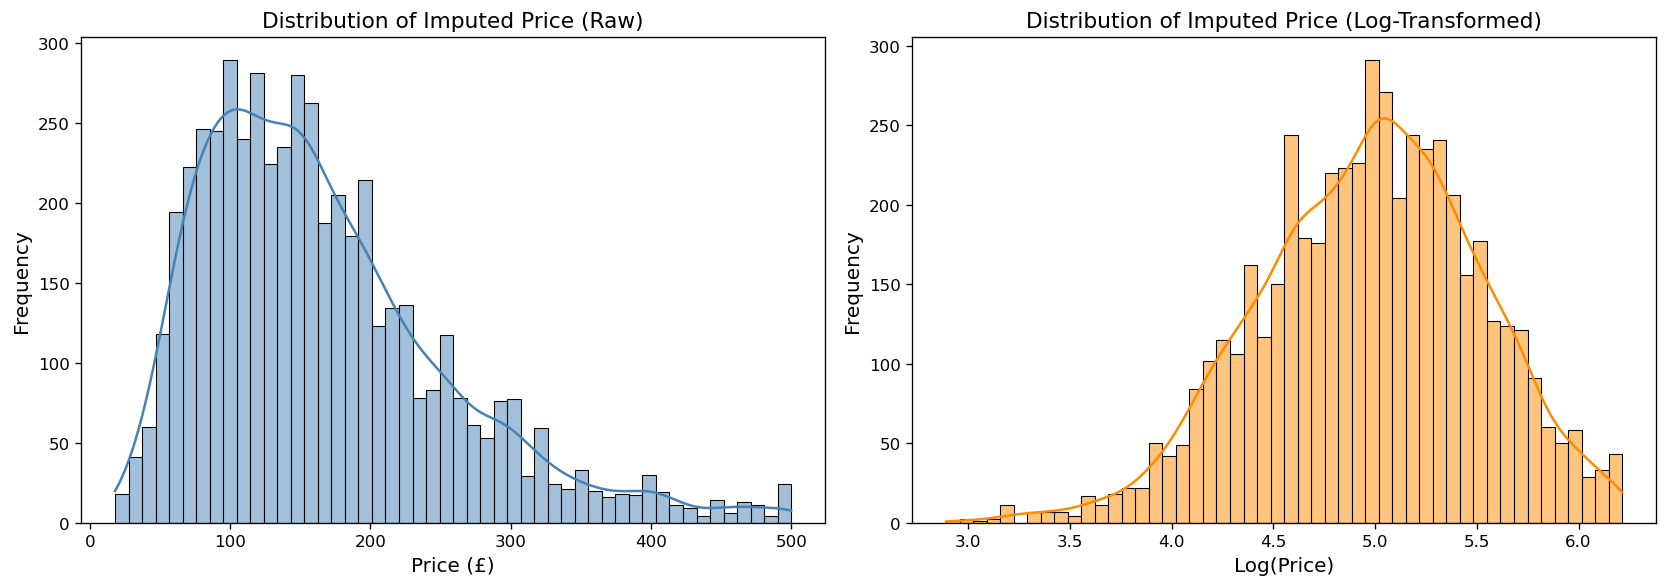

In [ ]:
# Price Distribution: (Raw vs Log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

sns.histplot(listings['price'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Imputed Price (Raw)', fontsize=13)
axes[0].set_xlabel('Price (£)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.histplot(listings['log_price'], bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Imputed Price (Log-Transformed)', fontsize=13)
axes[1].set_xlabel('Log(Price)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

In [46]:
listings.to_csv('Data/listings_cleaned(keer).csv', index=False)
print("Cleaned dataset saved to 'Data/listings_cleaned(keer).csv' Successfully!")

Cleaned dataset saved to 'Data/listings_cleaned(keer).csv' Successfully!


In [47]:
listings = pd.read_csv('Data/listings_cleaned(keer).csv')
print(listings.shape)
print(listings.columns)
listings.head()

(5138, 108)
Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       ...
       'amenity_coffee', 'amenity_backyard', 'amenity_outdoor_dining',
       'amenity_greets', 'amenity_pool', 'amenity_beachfront', 'amenity_patio',
       'amenity_luggage', 'amenity_furniture', 'log_price'],
      dtype='str', length=108)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,amenity_coffee,amenity_backyard,amenity_outdoor_dining,amenity_greets,amenity_pool,amenity_beachfront,amenity_patio,amenity_luggage,amenity_furniture,log_price
0,24288,https://www.airbnb.com/rooms/24288,20241018023128,2024-10-18,city scrape,"Cool central Loft, sleeps 4, 2 double bed+en-s...",Upper level of duplex. Boho rustic-chic former...,"Boho, studenty, lively, cool neighbourhood",https://a0.muscache.com/pictures/3460007/88731...,46498,...,0,0,0,0,0,0,0,0,0,4.644391
1,38628,https://www.airbnb.com/rooms/38628,20241018023128,2024-10-18,city scrape,Edinburgh Holiday Let,Self contained studio 6 minutes by train to Ed...,Quiet and easy access to outside. Fort Kinnair...,https://a0.muscache.com/pictures/hosting/Hosti...,165635,...,0,0,0,0,0,0,0,0,0,4.595120
2,51505,https://www.airbnb.com/rooms/51505,20241018023128,2024-10-18,previous scrape,Superb City Centre Apartment,Fantastically central apartment in an historic...,Hanover Street is wonderfully located in the c...,https://a0.muscache.com/pictures/bc26fbc9-38a3...,236828,...,0,0,0,0,0,0,0,0,0,5.422922
3,54188,https://www.airbnb.com/rooms/54188,20241018023128,2024-10-18,city scrape,The Four Sisters Boatel,"A first for Scotland, The Four Sisters Boatel ...",The Four Sisters Boatel Is moored in The Lochr...,https://a0.muscache.com/pictures/868604d2-7951...,253850,...,1,0,0,0,0,0,0,0,0,5.416100
4,55881,https://www.airbnb.com/rooms/55881,20241018023128,2024-10-18,city scrape,Lovely central apartment sleeps 5,Lovely characterful Victorian tenement apartme...,NaN,https://a0.muscache.com/pictures/84332374/f268...,264345,...,0,0,0,0,0,0,0,0,0,5.501258


In [48]:
listings.to_csv('Data/listings_cleaned(keer).csv.gz', index=False, compression='gzip')
print(f"Saved! Shape: {listings.shape}")

Saved! Shape: (5138, 108)
